/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/20
88/88 ━━━━━━━━━━━━━━━━━━━━ 5s 18ms/step - accuracy: 0.1699 - loss: 0.8075 - val_accuracy: 0.2136 - val_loss: 0.7319
Epoch 2/20
88/88 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.3694 - loss: 0.7009 - val_accuracy: 0.4727 - val_loss: 0.6698
Epoch 3/20
88/88 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.5564 - loss: 0.6390 - val_accuracy: 0.5364 - val_loss: 0.6198
Epoch 4/20
88/88 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.5656 - loss: 0.5843 - val_accuracy: 0.5364 - val_loss: 0.5709
Epoch 5/20
88/88 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.5656 - loss: 0.5328 - val_accuracy: 0.5364 - val_loss: 0.5243
Epoch 6/20
88/88 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6294 - loss: 0.4859 - val_accuracy: 0.8727 - val_loss: 0.4792
Epoch 7/20
88/88 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8905 - loss: 0.4428 - val_accuracy: 0.9273 - val_loss: 0.4368
Epoch 8/20
88/88 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9327 - loss: 0.4033 - val_accuracy: 0.9455 - val_loss

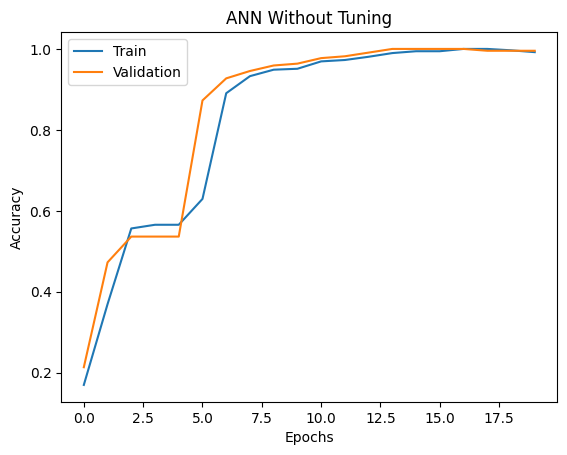

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

# Load dataset
url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/banknote_authentication.csv"
df = pd.read_csv(url, header=None)
df.columns = ['variance', 'skewness', 'curtosis', 'entropy', 'class']

# Preprocessing
X = df.drop('class', axis=1)
y = df['class']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# ANN Model
model = Sequential()
model.add(Dense(8, activation='relu', input_dim=4))
model.add(Dense(4, activation='relu'))
model.add(Dense(1, activation='sigmoid'))

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Train
history1 = model.fit(X_train, y_train, epochs=20, batch_size=10, validation_split=0.2)

# Evaluate
loss1, acc1 = model.evaluate(X_test, y_test)
print("WITHOUT TUNING Accuracy:", acc1)

# Graph
plt.figure()
plt.plot(history1.history['accuracy'], label='Train')
plt.plot(history1.history['val_accuracy'], label='Validation')
plt.title("ANN Without Tuning")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.show()


Epoch 1/30
176/176 ━━━━━━━━━━━━━━━━━━━━ 8s 15ms/step - accuracy: 0.8712 - loss: 0.4691 - val_accuracy: 0.9364 - val_loss: 0.3404
Epoch 2/30
176/176 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.9487 - loss: 0.2187 - val_accuracy: 0.9500 - val_loss: 0.1516
Epoch 3/30
176/176 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - accuracy: 0.9658 - loss: 0.1118 - val_accuracy: 0.9864 - val_loss: 0.0789
Epoch 4/30
176/176 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.9772 - loss: 0.0714 - val_accuracy: 0.9955 - val_loss: 0.0478
Epoch 5/30
176/176 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.9886 - loss: 0.0487 - val_accuracy: 0.9955 - val_loss: 0.0319
Epoch 6/30
176/176 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9920 - loss: 0.0354 - val_accuracy: 0.9955 - val_loss: 0.0241
Epoch 7/30
176/176 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9966 - loss: 0.0270 - val_accuracy: 0.9955 - val_loss: 0.0183
Epoch 8/30
176/176 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - accuracy: 0.9989 - loss: 0.0209 - val_accura

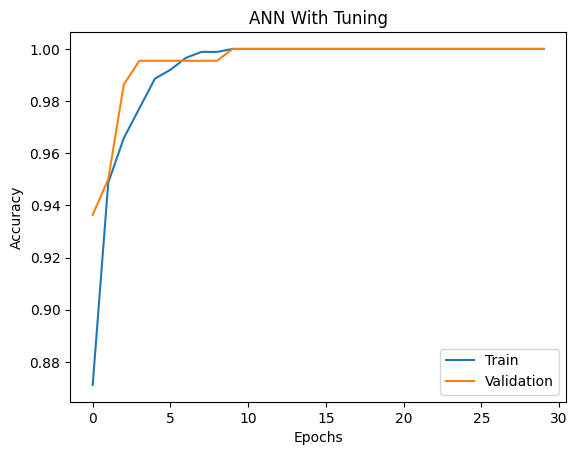

In [2]:
# Tuned Model (changed neurons, epochs, batch size)

model2 = Sequential()
model2.add(Dense(16, activation='relu', input_dim=4))
model2.add(Dense(8, activation='relu'))
model2.add(Dense(1, activation='sigmoid'))

model2.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Train with different parameters
history2 = model2.fit(X_train, y_train, epochs=30, batch_size=5, validation_split=0.2)

# Evaluate
loss2, acc2 = model2.evaluate(X_test, y_test)
print("WITH TUNING Accuracy:", acc2)

# Graph
plt.figure()
plt.plot(history2.history['accuracy'], label='Train')
plt.plot(history2.history['val_accuracy'], label='Validation')
plt.title("ANN With Tuning")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.show()
